In [1]:
# Create Flirt Prediction Model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
# Load dataset

In [4]:
df = pd.read_csv(
    "SMS_Labelled_Dataset.csv",
    encoding="utf-8-sig"
)

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

df.head()

Dataset Shape: (5000, 5)

Column Names:
['Sender', 'Message', 'Date', 'Timestamp', 'Flirt_Label']


,Sender,Message,Date,Timestamp,Flirt_Label
0,Anna,"Funny fact Nobody teaches volcanoes 2 erupt, t...",02-02-2025,02-02-2025 21:07,0
1,Anna,I sent my scores to sophas and i had to do sec...,10-10-2025,10-10-2025 13:39,0
2,Isaac,We know someone who you know that fancies you....,28-08-2025,28-08-2025 00:48,0
3,Anna,Only if you promise your getting out as SOON a...,10-06-2025,10-06-2025 09:03,0
4,Isaac,Congratulations ur awarded either Ã¥Â£500 of C...,08-06-2025,08-06-2025 05:44,0


In [5]:
# Clean dataset

In [7]:
# 1. Remove unwanted characters/spaces from column names

df.columns = (
    df.columns
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

df.rename(
    columns={
        "ï»¿Sender": "Sender"
    },
    inplace=True
)
print(df.columns.tolist())

['Sender', 'Message', 'Date', 'Timestamp', 'Flirt_Label']


In [8]:
# 2. Fill missing values

df["Sender"] = df["Sender"].fillna("").astype(str)
df["Message"] = df["Message"].fillna("").astype(str)

# Convert Flirt_Label to numeric
df["Flirt_Label"] = pd.to_numeric(
    df["Flirt_Label"],
    errors="coerce"
)

# Remove rows where the target label is missing
df = df.dropna(subset=["Flirt_Label"])
df["Flirt_Label"] = df["Flirt_Label"].astype(int)
print("Dataset Shape after cleaning:", df.shape)

print(df["Flirt_Label"].value_counts())

Dataset Shape after cleaning: (5000, 5)
Flirt_Label
0    4457
1     543
Name: count, dtype: int64


In [10]:
print("Sample Flirt Messages:")
display(
    df[df["Flirt_Label"] == 1][
        ["Sender", "Message"]
    ].head(10)
)

print("\nSample Not-Flirt Messages:")
display(
    df[df["Flirt_Label"] == 0][
        ["Sender", "Message"]
    ].head(10)
)

Sample Flirt Messages:


,Sender,Message
21,Anna,Boy; I love u Grl: Hogolo Boy: gold chain kods...
22,Anna,A bloo bloo bloo I'll miss the first bowl
25,Anna,No it was cancelled yeah baby! Well that sound...
32,Isaac,Hi I'm sue. I am 20 years old and work as a la...
40,Anna,"see, i knew giving you a break a few times wou..."
63,Anna,But i have to. I like to have love and arrange.
64,Anna,HI DARLIN I HOPE YOU HAD A NICE NIGHT I WISH I...
68,Anna,Awesome question with a cute answer: Someone a...
73,Anna,Honeybee Said: *I'm d Sweetest in d World* God...
74,Anna,"THATÃ¥ÃS ALRITE GIRL, U KNOW GAIL IS NEVA WRO..."



Sample Not-Flirt Messages:


,Sender,Message
0,Anna,"Funny fact Nobody teaches volcanoes 2 erupt, t..."
1,Anna,I sent my scores to sophas and i had to do sec...
2,Isaac,We know someone who you know that fancies you....
3,Anna,Only if you promise your getting out as SOON a...
4,Isaac,Congratulations ur awarded either Ã¥Â£500 of C...
5,Anna,"I'll text carlos and let you know, hang on"
6,Anna,K.i did't see you.:)k:)where are you now?
7,Anna,No message..no responce..what happend?
8,Anna,Get down in gandhipuram and walk to cross cut ...
9,Anna,You flippin your shit yet?


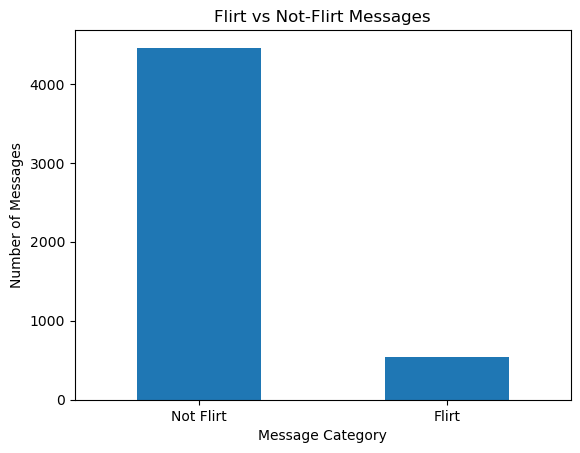

In [12]:
# Flirt Label Distribution
label_counts = df["Flirt_Label"].value_counts()

label_counts.index = [
    "Not Flirt" if x == 0 else "Flirt"
    for x in label_counts.index
]

label_counts.plot(kind="bar")

plt.title("Flirt vs Not-Flirt Messages")
plt.xlabel("Message Category")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.show()

In [14]:
# Train-Test Split

In [15]:
X = df["Message"]
y = df["Flirt_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 4000
Testing Records: 1000


In [16]:
# Model 1 — CountVectorizer + Naive Bayes

In [17]:
# Count Vectorizer

count_vectorizer = CountVectorizer(
    stop_words="english"
)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

# Naive Bayes
nb_count_model = MultinomialNB()

nb_count_model.fit(
    X_train_count,
    y_train
)

y_pred_nb_count = nb_count_model.predict(
    X_test_count
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_nb_count,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       891
           1       0.83      0.72      0.77       109

    accuracy                           0.95      1000
   macro avg       0.90      0.85      0.87      1000
weighted avg       0.95      0.95      0.95      1000



In [18]:
# Model 2 — CountVectorizer + Logistic Regression

In [19]:
lr_count_model = LogisticRegression(
    max_iter=1000
)

lr_count_model.fit(
    X_train_count,
    y_train
)

y_pred_lr_count = lr_count_model.predict(
    X_test_count
)

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr_count,
        zero_division=0
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       891
           1       0.96      0.60      0.73       109

    accuracy                           0.95      1000
   macro avg       0.95      0.80      0.85      1000
weighted avg       0.95      0.95      0.95      1000



In [20]:
# Model 3 — TF-IDF + Naive Bayes

In [21]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english"
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)


nb_tfidf_model = MultinomialNB()

nb_tfidf_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_nb_tfidf = nb_tfidf_model.predict(
    X_test_tfidf
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_nb_tfidf,
        zero_division=0
    )
)

Training feature shape: (4000, 6949)
Testing feature shape: (1000, 6949)

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       891
           1       1.00      0.06      0.12       109

    accuracy                           0.90      1000
   macro avg       0.95      0.53      0.53      1000
weighted avg       0.91      0.90      0.86      1000



In [22]:
# Model 4 — TF-IDF + Logistic Regression

In [23]:
lr_tfidf_model = LogisticRegression(
    max_iter=1000
)

lr_tfidf_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_lr_tfidf = lr_tfidf_model.predict(
    X_test_tfidf
)

print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_lr_tfidf,
        zero_division=0
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       891
           1       1.00      0.29      0.45       109

    accuracy                           0.92      1000
   macro avg       0.96      0.65      0.71      1000
weighted avg       0.93      0.92      0.90      1000



In [24]:
# Model 5 — TF-IDF + Linear SVM

In [25]:
svm_model = LinearSVC()

svm_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_svm = svm_model.predict(
    X_test_tfidf
)

print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_svm,
        zero_division=0
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       891
           1       1.00      0.71      0.83       109

    accuracy                           0.97      1000
   macro avg       0.98      0.85      0.91      1000
weighted avg       0.97      0.97      0.97      1000



In [26]:
# Compare all models

In [27]:
results = []

models = {
    "CountVectorizer + Naive Bayes": y_pred_nb_count,
    "CountVectorizer + Logistic Regression": y_pred_lr_count,
    "TF-IDF + Naive Bayes": y_pred_nb_tfidf,
    "TF-IDF + Logistic Regression": y_pred_lr_tfidf,
    "TF-IDF + Linear SVM": y_pred_svm
}

for model_name, predictions in models.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,CountVectorizer + Naive Bayes,0.953,0.829787,0.715596,0.768473
1,CountVectorizer + Logistic Regression,0.953,0.955882,0.596330,0.734463
2,TF-IDF + Naive Bayes,0.898,1.000000,0.064220,0.120690
3,TF-IDF + Logistic Regression,0.923,1.000000,0.293578,0.453901
4,TF-IDF + Linear SVM,0.968,1.000000,0.706422,0.827957


In [28]:
# Visual Model Comparison

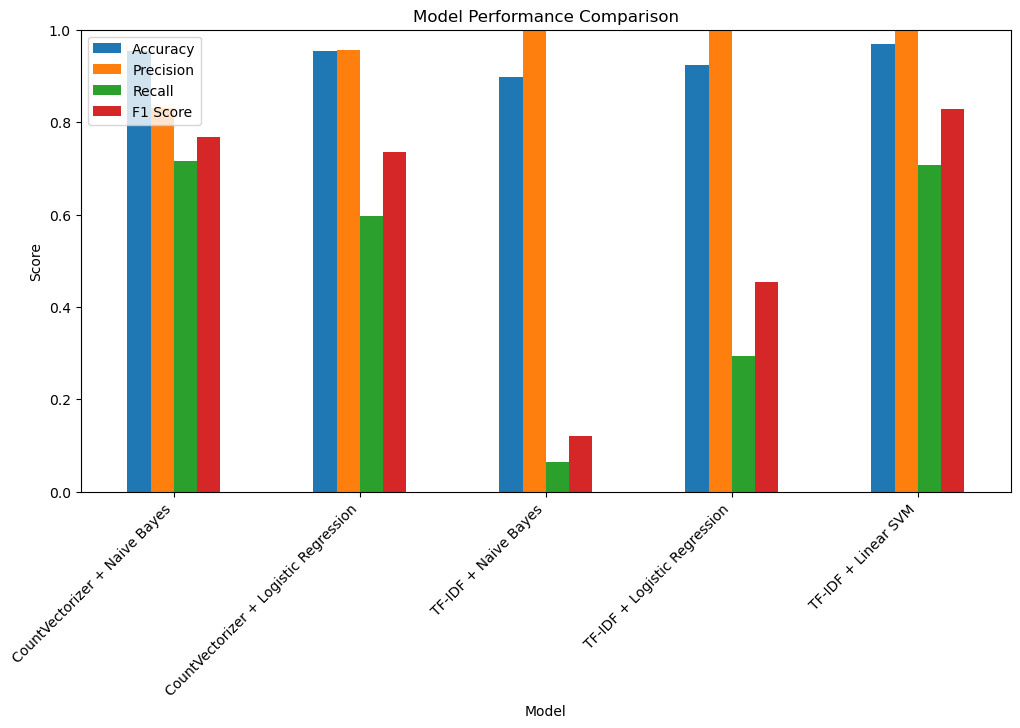

In [29]:
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [30]:
# Select the Final Model Automatically

In [31]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("Selected Final Model:")
print(best_model_name)

Selected Final Model:
TF-IDF + Linear SVM


In [32]:
# Train the Final Model Using All SMS Data

In [33]:
if best_model_name == "CountVectorizer + Naive Bayes":

    final_vectorizer = CountVectorizer(
        stop_words="english"
    )

    X_all = final_vectorizer.fit_transform(
        df["Message"]
    )

    final_model = MultinomialNB()

elif best_model_name == "CountVectorizer + Logistic Regression":

    final_vectorizer = CountVectorizer(
        stop_words="english"
    )

    X_all = final_vectorizer.fit_transform(
        df["Message"]
    )

    final_model = LogisticRegression(
        max_iter=1000
    )

elif best_model_name == "TF-IDF + Naive Bayes":

    final_vectorizer = TfidfVectorizer(
        stop_words="english"
    )

    X_all = final_vectorizer.fit_transform(
        df["Message"]
    )

    final_model = MultinomialNB()

elif best_model_name == "TF-IDF + Logistic Regression":

    final_vectorizer = TfidfVectorizer(
        stop_words="english"
    )

    X_all = final_vectorizer.fit_transform(
        df["Message"]
    )

    final_model = LogisticRegression(
        max_iter=1000
    )

else:

    final_vectorizer = TfidfVectorizer(
        stop_words="english"
    )

    X_all = final_vectorizer.fit_transform(
        df["Message"]
    )

    final_model = LinearSVC()


final_model.fit(
    X_all,
    df["Flirt_Label"]
)

print("Final model trained successfully.")

Final model trained successfully.


In [34]:
# Predict Flirt / Not Flirt for Every SMS

In [36]:
df["Predicted_Flirt_Label"] = final_model.predict(
    X_all
)

df["Predicted_Flirt"] = df[
    "Predicted_Flirt_Label"
].map({
    0: "Not Flirt",
    1: "Flirt"
})

display(
    df[
        [
            "Sender",
            "Message",
            "Date",
            "Timestamp",
            "Predicted_Flirt"
        ]
    ].head(30)
)

,Sender,Message,Date,Timestamp,Predicted_Flirt
0,Anna,"Funny fact Nobody teaches volcanoes 2 erupt, t...",02-02-2025,02-02-2025 21:07,Not Flirt
1,Anna,I sent my scores to sophas and i had to do sec...,10-10-2025,10-10-2025 13:39,Not Flirt
2,Isaac,We know someone who you know that fancies you....,28-08-2025,28-08-2025 00:48,Not Flirt
3,Anna,Only if you promise your getting out as SOON a...,10-06-2025,10-06-2025 09:03,Not Flirt
4,Isaac,Congratulations ur awarded either Ã¥Â£500 of C...,08-06-2025,08-06-2025 05:44,Not Flirt
5,Anna,"I'll text carlos and let you know, hang on",10-11-2025,10-11-2025 10:26,Not Flirt
6,Anna,K.i did't see you.:)k:)where are you now?,01-02-2025,01-02-2025 16:11,Not Flirt
7,Anna,No message..no responce..what happend?,12-09-2025,12-09-2025 15:21,Not Flirt
8,Anna,Get down in gandhipuram and walk to cross cut ...,15-03-2025,15-03-2025 19:15,Not Flirt
9,Anna,You flippin your shit yet?,04-02-2025,04-02-2025 16:14,Not Flirt


In [37]:
df["Predicted_Flirt"].value_counts()

Predicted_Flirt
Not Flirt    4460
Flirt         540
Name: count, dtype: int64

In [38]:
# Talkative and Less Talkative

In [39]:
sender_counts = (
    df["Sender"]
    .value_counts()
    .reset_index()
)

sender_counts.columns = [
    "Sender",
    "Message_Count"
]

sender_counts

,Sender,Message_Count
0,Anna,4326
1,Isaac,674


In [41]:
# Most talkative

most_talkative = sender_counts.iloc[0]

print(
    "Most Talkative Person:",
    most_talkative["Sender"]
)

print(
    "Number of Messages:",
    most_talkative["Message_Count"]
)

Most Talkative Person: Anna
Number of Messages: 4326


In [42]:
# Less talkative

least_talkative = sender_counts.iloc[-1]

print(
    "Less Talkative Person:",
    least_talkative["Sender"]
)

print(
    "Number of Messages:",
    least_talkative["Message_Count"]
)

Less Talkative Person: Isaac
Number of Messages: 674


In [43]:
# Most Active Day

In [44]:
# Convert Date to datetime format

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

# Count messages by date

daily_activity = (
    df["Date"]
    .dt.date
    .value_counts()
    .sort_index()
)

# Find most active date

most_active_date = daily_activity.idxmax()
most_active_date_count = daily_activity.max()

print(
    "Most Active Day:",
    most_active_date
)

print(
    "Number of Messages:",
    most_active_date_count
)

Most Active Day: 2025-12-17
Number of Messages: 26


In [45]:
# Most Active Time

In [47]:
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    dayfirst=True,
    errors="coerce"
)

# Extract hour

df["Hour"] = df["Timestamp"].dt.hour

# Count messages by hour

hourly_activity = (
    df["Hour"]
    .value_counts()
    .sort_index()
)

# Find most active hour

most_active_hour = hourly_activity.idxmax()
most_active_hour_count = hourly_activity.max()

print(
    "Most Active Hour:",
    most_active_hour
)

print(
    "Number of Messages:",
    most_active_hour_count
)

Most Active Hour: 13
Number of Messages: 230


In [48]:
hourly_activity

Hour
0     196
1     223
2     211
3     179
4     222
5     203
6     207
7     225
8     193
9     221
10    202
11    223
12    207
13    230
14    208
15    188
16    216
17    210
18    200
19    220
20    191
21    218
22    205
23    202
Name: count, dtype: int64

In [51]:
# Media Count by Person

In [49]:
media_keywords = [
    "<media omitted>",
    "image omitted",
    "video omitted",
    "audio omitted",
    "sticker omitted",
    "photo omitted",
    "media omitted"
]


def check_media(message):

    message = str(message).lower()

    for keyword in media_keywords:

        if keyword in message:
            return 1

    return 0


df["Media_Flag"] = df["Message"].apply(
    check_media
)

In [50]:
media_by_sender = (
    df.groupby("Sender")["Media_Flag"]
    .sum()
    .reset_index()
)

media_by_sender.columns = [
    "Sender",
    "Media_Count"
]

media_by_sender

,Sender,Media_Count
0,Anna,0
1,Isaac,0


In [52]:
# Identify Missed Calls

In [55]:
missed_call_keywords = [
    "missed call",
    "missed a call",
    "missed your call",
    "you missed a call",
    "miss call"
]


def check_missed_call(message):

    message = str(message).lower()

    for keyword in missed_call_keywords:

        if keyword in message:
            return 1

    return 0


df["Missed_Call_Flag"] = df["Message"].apply(
    check_missed_call
)

missed_calls = df[
    df["Missed_Call_Flag"] == 1
][
    [
        "Sender",
        "Message",
        "Date",
        "Timestamp"
    ]
]

print(
    "Missed-call related messages:",
    len(missed_calls)
)

Missed-call related messages: 12


In [56]:
missed_calls_by_sender = (
    df.groupby("Sender")["Missed_Call_Flag"]
    .sum()
    .reset_index()
)

missed_calls_by_sender.columns = [
    "Sender",
    "Missed_Call_Count"
]

missed_calls_by_sender

,Sender,Missed_Call_Count
0,Anna,10
1,Isaac,2


In [57]:
# Final dataset

In [65]:
final_columns = [
    "Sender",
    "Message",
    "Date",
    "Timestamp",
    "Flirt_Label",
    "Predicted_Flirt_Label",
    "Predicted_Flirt",
    "Hour",
    "Media_Flag",
    "Missed_Call_Flag"
]

final_df = df[final_columns]

display(final_df.head(30))

,Sender,Message,Date,Timestamp,Flirt_Label,Predicted_Flirt_Label,Predicted_Flirt,Hour,Media_Flag,Missed_Call_Flag
0,Anna,"Funny fact Nobody teaches volcanoes 2 erupt, t...",2025-02-02,2025-02-02 21:07:00,0,0,Not Flirt,21,0,0
1,Anna,I sent my scores to sophas and i had to do sec...,2025-10-10,2025-10-10 13:39:00,0,0,Not Flirt,13,0,0
2,Isaac,We know someone who you know that fancies you....,2025-08-28,2025-08-28 00:48:00,0,0,Not Flirt,0,0,0
3,Anna,Only if you promise your getting out as SOON a...,2025-06-10,2025-06-10 09:03:00,0,0,Not Flirt,9,0,0
4,Isaac,Congratulations ur awarded either Ã¥Â£500 of C...,2025-06-08,2025-06-08 05:44:00,0,0,Not Flirt,5,0,0
5,Anna,"I'll text carlos and let you know, hang on",2025-11-10,2025-11-10 10:26:00,0,0,Not Flirt,10,0,0
6,Anna,K.i did't see you.:)k:)where are you now?,2025-02-01,2025-02-01 16:11:00,0,0,Not Flirt,16,0,0
7,Anna,No message..no responce..what happend?,2025-09-12,2025-09-12 15:21:00,0,0,Not Flirt,15,0,0
8,Anna,Get down in gandhipuram and walk to cross cut ...,2025-03-15,2025-03-15 19:15:00,0,0,Not Flirt,19,0,0
9,Anna,You flippin your shit yet?,2025-02-04,2025-02-04 16:14:00,0,0,Not Flirt,16,0,0


In [60]:
# Save final results

In [61]:
output_file = "Final_SMS_Flirt_Analysis.csv"

final_df.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Final dataset saved as:",
    output_file
)

Final dataset saved as: Final_SMS_Flirt_Analysis.csv
